# MISSING INDICATOR IMPUTATION:

In [117]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/faizanhaider01/klssss/placement_modified.csv


In [118]:
df = pd.read_csv('/kaggle/input/datasets/faizanhaider01/klssss/placement_modified.csv',usecols=['cgpa','iq','placement'])

In [119]:
df.sample(5)

,cgpa,iq,placement
20,6.6,120.0,1
28,5.2,90.0,0
75,4.8,169.0,0
8,6.1,156.0,0
95,4.3,200.0,0


In [120]:
df.isnull().mean()*100

cgpa         8.0
iq           7.0
placement    0.0
dtype: float64

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.impute import MissingIndicator,SimpleImputer

In [122]:
X = df.drop(columns=['placement'])
y = df['placement']

In [123]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [124]:
X_train.sample(4)

,cgpa,iq
60,6.9,139.0
19,5.2,132.0
81,5.4,107.0
85,5.8,166.0


In [125]:
si = SimpleImputer()
X_train_trf = si.fit_transform(X_train)
X_test_trf = si.transform(X_test)

In [126]:
X_train_trf

array([[  6.8       ,  90.        ],
       [  6.9       , 138.        ],
       [  5.7       , 169.        ],
       [  7.5       ,  61.        ],
       [  4.9       , 127.16      ],
       [  7.1       , 127.16      ],
       [  5.        ,  91.        ],
       [  7.3       ,  50.        ],
       [  5.96111111, 154.        ],
       [  6.        , 102.        ],
       [  8.1       , 166.        ],
       [  5.9       , 106.        ],
       [  4.        , 100.        ],
       [  6.6       , 138.        ],
       [  5.7       , 140.        ],
       [  6.1       ,  81.        ],
       [  5.7       , 143.        ],
       [  5.96111111, 151.        ],
       [  7.5       , 158.        ],
       [  5.96111111,  45.        ],
       [  5.96111111, 139.        ],
       [  8.3       , 168.        ],
       [  5.7       , 132.        ],
       [  6.4       , 141.        ],
       [  4.3       , 200.        ],
       [  7.        , 139.        ],
       [  5.2       , 132.        ],
 

In [127]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train_trf,y_train)

y_pred = clf.predict(X_test_trf)

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)*100

90.0

In [128]:
mi = MissingIndicator()

In [129]:
mi.fit(X_train)

MissingIndicator()

In [130]:
mi.features_

array([0, 1])

In [131]:
X_train_missing = mi.transform(X_train)

In [132]:
X_train_missing

array([[False, False],
       [False, False],
       [False, False],
       [False, False],
       [False,  True],
       [False,  True],
       [False, False],
       [False, False],
       [ True, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [ True, False],
       [False, False],
       [ True, False],
       [ True, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [ True,  True],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [False, False],
       [Fal

In [133]:
X_test_missing = mi.transform(X_test)

In [134]:
X_train['cgpa_missing'] = X_train_missing[:, 0]
X_train['iq_missing']   = X_train_missing[:, 1]

In [135]:
# Add missing indicator columns to X_test (same as you did for X_train)
# X_test_missing is a numpy array, use column positions
X_test['cgpa_missing'] = X_test_missing[:, 0].astype(int)
X_test['iq_missing']   = X_test_missing[:, 1].astype(int)

In [136]:
X_train

,cgpa,iq,cgpa_missing,iq_missing
35,6.8,90.0,False,False
11,6.9,138.0,False,False
84,5.7,169.0,False,False
44,7.5,61.0,False,False
73,4.9,NaN,False,True
...,...,...,...,...
43,6.8,141.0,False,False
22,4.9,NaN,False,True
72,7.3,116.0,False,False
15,5.1,176.0,False,False


In [137]:
si = SimpleImputer()
X_train_trf2 = si.fit_transform(X_train)
X_test_trf2  = si.transform(X_test)

In [138]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

clf.fit(X_train_trf2,y_train)

y_pred = clf.predict(X_test_trf2)

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)*100   
#The missing indicator imputation increase model accuracy

95.0

In [139]:
#USING SKLEARN:
#si = SimpleImputer(add_indicator=True)

# Random Sample Imputation:

In [140]:
dfs = pd.read_csv('/kaggle/input/datasets/faizanhaider01/klssss/placement_modified.csv',usecols=['cgpa','iq','placement'])

In [141]:
dfs.head(4)

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,NaN,0
3,7.4,132.0,1


In [142]:
iq_filling = dfs['iq'].mean()

In [143]:
dfs['iq'].fillna(iq_filling,inplace=True)

In [144]:
dfs.isnull().mean()*100  
#we want only one column with missing values to be test easily so we filled the iq

cgpa         8.0
iq           0.0
placement    0.0
dtype: float64

In [145]:
X = dfs.drop(columns=['placement'])
y = dfs['placement']

In [146]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [147]:
X_train

,cgpa,iq
35,6.8,90.000000
11,6.9,138.000000
84,5.7,169.000000
44,7.5,61.000000
73,4.9,126.698925
...,...,...
43,6.8,141.000000
22,4.9,126.698925
72,7.3,116.000000
15,5.1,176.000000


In [148]:
X_train['cgpa_imputed'] = X_train['cgpa']
X_test['cgpa_imputed'] = X_test['cgpa']

In [149]:
X_train.sample(4)

,cgpa,iq,cgpa_imputed
66,6.9,96.000000,6.9
96,NaN,126.698925,NaN
45,6.0,66.000000,6.0
5,7.1,126.698925,7.1


In [150]:
X_train['cgpa_imputed'][X_train['cgpa_imputed'].isnull()] = X_train['cgpa'].dropna().sample(X_train['cgpa'].isnull().sum()).values
X_test['cgpa_imputed'][X_test['cgpa_imputed'].isnull()] = X_train['cgpa'].dropna().sample(X_test['cgpa'].isnull().sum()).values

In [151]:
X_train['cgpa'].dropna().sample(X_train['cgpa'].isnull().sum()).values

array([8.1, 6.6, 6.9, 7.3, 5.7, 4.3, 3.5, 7.5])

In [152]:
X_train['cgpa'].isnull().sum()

np.int64(8)

In [153]:
X_train.sample(5)

,cgpa,iq,cgpa_imputed
1,5.9,106.000000,5.9
46,5.3,114.000000,5.3
96,NaN,126.698925,5.1
12,NaN,139.000000,6.9
15,5.1,176.000000,5.1


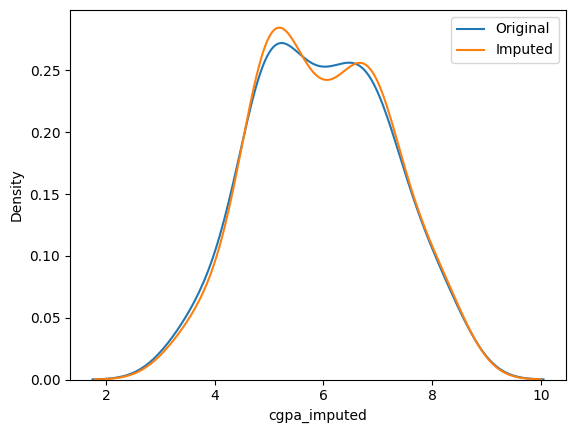

In [154]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.distplot(X_train['cgpa'],label='Original',hist=False)
sns.distplot(X_train['cgpa_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [155]:
print('Original variable variance: ', X_train['cgpa'].var())
print('Variance after random imputation: ', X_train['cgpa_imputed'].var())

Original variable variance:  1.4773395931142412
Variance after random imputation:  1.4555553797468361


In [157]:
X_train[['iq', 'cgpa', 'cgpa_imputed']].cov()

,iq,cgpa,cgpa_imputed
iq,1526.393374,-8.66382,-8.525649
cgpa,-8.663820,1.47734,1.477340
cgpa_imputed,-8.525649,1.47734,1.455555


<Axes: >

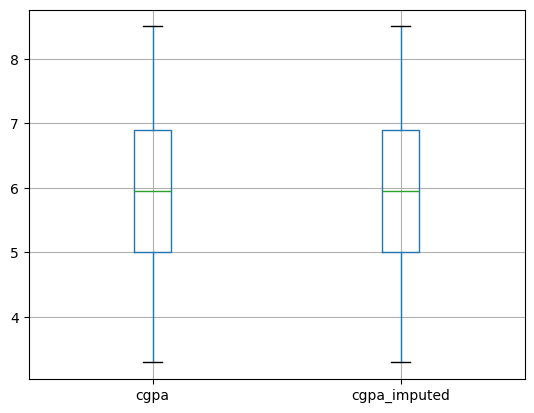

In [158]:
X_train[['cgpa', 'cgpa_imputed']].boxplot()